In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report, accuracy_score
import joblib

In [2]:
df=pd.read_csv(r"D:\Projects\Amazon sales dataset\amazon_products_sales_data_cleaned.csv")
df

,product_title,product_rating,total_reviews,purchased_last_month,discounted_price,original_price,is_best_seller,is_sponsored,has_coupon,buy_box_availability,delivery_date,sustainability_tags,product_image_url,product_page_url,data_collected_at,product_category,discount_percentage
0,BOYA BOYALINK 2 Wireless Lavalier Microphone f...,4.6,375.0,300.0,89.68,159.00,No Badge,Sponsored,Save 15% with coupon,Add to cart,01-09-2025,Carbon impact,https://m.media-amazon.com/images/I/71pAqiVEs3...,https://www.amazon.com/sspa/click?ie=UTF8&spc=...,21-08-2025 11:14,Phones,43.60
1,"LISEN USB C to Lightning Cable, 240W 4 in 1 Ch...",4.3,2457.0,6000.0,9.99,15.99,No Badge,Sponsored,No Coupon,Add to cart,29-08-2025,NaN,https://m.media-amazon.com/images/I/61nbF6aVIP...,https://www.amazon.com/sspa/click?ie=UTF8&spc=...,21-08-2025 11:14,Laptops,37.52
2,"DJI Mic 2 (2 TX + 1 RX + Charging Case), Wirel...",4.6,3044.0,2000.0,314.00,349.00,No Badge,Sponsored,No Coupon,Add to cart,01-09-2025,NaN,https://m.media-amazon.com/images/I/61h78MEXoj...,https://www.amazon.com/sspa/click?ie=UTF8&spc=...,21-08-2025 11:14,Laptops,10.03
3,"Apple AirPods Pro 2 Wireless Earbuds, Active N...",4.6,35882.0,10000.0,162.24,162.24,Best Seller,Organic,No Coupon,NaN,NaN,NaN,https://m.media-amazon.com/images/I/61SUj2aKoE...,https://www.amazon.com/Apple-Cancellation-Tran...,21-08-2025 11:14,Phones,0.00
4,Apple AirTag 4 Pack. Keep Track of and find Yo...,4.8,28988.0,10000.0,72.74,72.74,No Badge,Organic,No Coupon,NaN,NaN,NaN,https://m.media-amazon.com/images/I/61bMNCeAUA...,https://www.amazon.com/Apple-MX542LL-A-AirTag-...,21-08-2025 11:14,Phones,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42670,"Elgato 4K Pro, Internal Capture Card: 8K60 Pas...",5.0,1.0,100.0,195.99,195.99,No Badge,Organic,No Coupon,NaN,04-09-2025,NaN,https://m.media-amazon.com/images/I/51KCB+egEs...,https://www.amazon.com/Elgato-4K-Pro-Internal-...,30-08-2025 19:56,TV & Display,0.00
42671,"Arlo Essential Spotlight Camera, Wireless Secu...",4.2,20.0,200.0,89.99,89.99,No Badge,Organic,Save $25.00 with coupon,Add to cart,04-09-2025,NaN,https://m.media-amazon.com/images/I/51jV+o1LZE...,https://www.amazon.com/Arlo-Essential-Spotligh...,30-08-2025 19:56,Cameras,0.00
42672,"GIGABYTE - AORUS FO32U2-32"" QD OLED Gaming Mon...",4.3,57.0,50.0,899.99,1099.99,Save 18%,Organic,No Coupon,Add to cart,04-09-2025,NaN,https://m.media-amazon.com/images/I/71ySPkNLkG...,https://www.amazon.com/GIGABYTE-FO32U2-32-3840...,30-08-2025 19:56,Chargers & Cables,18.18
42673,Monoprice XLR Male to 1/4-Inch TRS Male Cable ...,4.7,7102.0,500.0,10.39,15.98,No Badge,Organic,No Coupon,Add to cart,04-09-2025,NaN,https://m.media-amazon.com/images/I/411c0JFJ79...,https://www.amazon.com/Monoprice-XLR-Male-4-In...,30-08-2025 19:56,Chargers & Cables,34.98


In [3]:
df.shape

(42675, 17)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42675 entries, 0 to 42674
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   product_title         42675 non-null  object 
 1   product_rating        41651 non-null  float64
 2   total_reviews         41651 non-null  float64
 3   purchased_last_month  32164 non-null  float64
 4   discounted_price      40613 non-null  float64
 5   original_price        40613 non-null  float64
 6   is_best_seller        42675 non-null  object 
 7   is_sponsored          42675 non-null  object 
 8   has_coupon            42675 non-null  object 
 9   buy_box_availability  28022 non-null  object 
 10  delivery_date         30692 non-null  object 
 11  sustainability_tags   3408 non-null   object 
 12  product_image_url     42675 non-null  object 
 13  product_page_url      40606 non-null  object 
 14  data_collected_at     42675 non-null  object 
 15  product_category   

In [5]:
df.head(3)

,product_title,product_rating,total_reviews,purchased_last_month,discounted_price,original_price,is_best_seller,is_sponsored,has_coupon,buy_box_availability,delivery_date,sustainability_tags,product_image_url,product_page_url,data_collected_at,product_category,discount_percentage
0,BOYA BOYALINK 2 Wireless Lavalier Microphone f...,4.6,375.0,300.0,89.68,159.00,No Badge,Sponsored,Save 15% with coupon,Add to cart,01-09-2025,Carbon impact,https://m.media-amazon.com/images/I/71pAqiVEs3...,https://www.amazon.com/sspa/click?ie=UTF8&spc=...,21-08-2025 11:14,Phones,43.60
1,"LISEN USB C to Lightning Cable, 240W 4 in 1 Ch...",4.3,2457.0,6000.0,9.99,15.99,No Badge,Sponsored,No Coupon,Add to cart,29-08-2025,NaN,https://m.media-amazon.com/images/I/61nbF6aVIP...,https://www.amazon.com/sspa/click?ie=UTF8&spc=...,21-08-2025 11:14,Laptops,37.52
2,"DJI Mic 2 (2 TX + 1 RX + Charging Case), Wirel...",4.6,3044.0,2000.0,314.00,349.00,No Badge,Sponsored,No Coupon,Add to cart,01-09-2025,NaN,https://m.media-amazon.com/images/I/61h78MEXoj...,https://www.amazon.com/sspa/click?ie=UTF8&spc=...,21-08-2025 11:14,Laptops,10.03


In [6]:
df.tail(3)

,product_title,product_rating,total_reviews,purchased_last_month,discounted_price,original_price,is_best_seller,is_sponsored,has_coupon,buy_box_availability,delivery_date,sustainability_tags,product_image_url,product_page_url,data_collected_at,product_category,discount_percentage
42672,"GIGABYTE - AORUS FO32U2-32"" QD OLED Gaming Mon...",4.3,57.0,50.0,899.99,1099.99,Save 18%,Organic,No Coupon,Add to cart,04-09-2025,NaN,https://m.media-amazon.com/images/I/71ySPkNLkG...,https://www.amazon.com/GIGABYTE-FO32U2-32-3840...,30-08-2025 19:56,Chargers & Cables,18.18
42673,Monoprice XLR Male to 1/4-Inch TRS Male Cable ...,4.7,7102.0,500.0,10.39,15.98,No Badge,Organic,No Coupon,Add to cart,04-09-2025,NaN,https://m.media-amazon.com/images/I/411c0JFJ79...,https://www.amazon.com/Monoprice-XLR-Male-4-In...,30-08-2025 19:56,Chargers & Cables,34.98
42674,Lorex Fusion 1080p HD Security Camera System w...,4.4,75.0,50.0,419.99,499.99,No Badge,Organic,No Coupon,Add to cart,04-09-2025,NaN,https://m.media-amazon.com/images/I/71wTn+zoSr...,https://www.amazon.com/Lorex-8-Channel-Securit...,30-08-2025 19:56,Cameras,16.00


In [7]:
df.describe()

,product_rating,total_reviews,purchased_last_month,discounted_price,original_price,discount_percentage
count,41651.000000,41651.000000,32164.000000,40613.000000,40613.000000,40613.000000
mean,4.399431,3087.106000,1293.665278,243.227289,257.611107,6.547151
std,0.386997,13030.460133,6318.323574,473.351545,496.633495,12.744715
min,1.000000,1.000000,50.000000,2.160000,2.160000,0.000000
25%,4.200000,82.000000,100.000000,29.690000,32.990000,0.000000
50%,4.500000,343.000000,200.000000,84.990000,89.000000,0.000000
75%,4.700000,1886.000000,400.000000,224.000000,229.990000,8.490000
max,5.000000,865598.000000,100000.000000,5449.000000,5449.000000,85.420000


In [8]:

df.drop(columns=['product_image_url','product_page_url','data_collected_at','delivery_date','sustainability_tags'], inplace=True)


In [9]:
df.drop(columns=['buy_box_availability'],inplace=True)

In [10]:
df.duplicated().sum()

np.int64(33207)

In [11]:
df.drop_duplicates(inplace=True)

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.isnull().sum()

product_title              0
product_rating            68
total_reviews             68
purchased_last_month    1183
discounted_price         449
original_price           449
is_best_seller             0
is_sponsored               0
has_coupon                 0
product_category           0
discount_percentage      449
dtype: int64

In [15]:
df.dropna(subset=['product_rating'], inplace=True)

In [16]:
df['total_reviews'] = df['total_reviews'].fillna(df['total_reviews'].median())
df['purchased_last_month'] = df['purchased_last_month'].fillna(df['purchased_last_month'].median())
df['discounted_price'] = df['discounted_price'].fillna(df['discounted_price'].median())
df['original_price'] = df['original_price'].fillna(df['original_price'].median())
df['discount_percentage'] = df['discount_percentage'].fillna(df['discount_percentage'].median())


In [17]:
df.isnull().sum()

product_title           0
product_rating          0
total_reviews           0
purchased_last_month    0
discounted_price        0
original_price          0
is_best_seller          0
is_sponsored            0
has_coupon              0
product_category        0
discount_percentage     0
dtype: int64

In [18]:
df.reset_index(drop=True, inplace=True)

In [19]:
df.shape

(9400, 11)

In [28]:
rec_df = df.drop_duplicates(subset='product_title').copy()
rec_df.reset_index(drop=True, inplace=True)


In [29]:
rec_df.shape


(8745, 12)

In [30]:
rec_df.head()

,product_title,product_rating,total_reviews,purchased_last_month,discounted_price,original_price,is_best_seller,is_sponsored,has_coupon,product_category,discount_percentage,combined_text
0,BOYA BOYALINK 2 Wireless Lavalier Microphone f...,4.6,375.0,300.0,89.68,159.00,No Badge,Sponsored,Save 15% with coupon,Phones,43.60,BOYA BOYALINK 2 Wireless Lavalier Microphone f...
1,"LISEN USB C to Lightning Cable, 240W 4 in 1 Ch...",4.3,2457.0,6000.0,9.99,15.99,No Badge,Sponsored,No Coupon,Laptops,37.52,"LISEN USB C to Lightning Cable, 240W 4 in 1 Ch..."
2,"DJI Mic 2 (2 TX + 1 RX + Charging Case), Wirel...",4.6,3044.0,2000.0,314.00,349.00,No Badge,Sponsored,No Coupon,Laptops,10.03,"DJI Mic 2 (2 TX + 1 RX + Charging Case), Wirel..."
3,"Apple AirPods Pro 2 Wireless Earbuds, Active N...",4.6,35882.0,10000.0,162.24,162.24,Best Seller,Organic,No Coupon,Phones,0.00,"Apple AirPods Pro 2 Wireless Earbuds, Active N..."
4,Apple AirTag 4 Pack. Keep Track of and find Yo...,4.8,28988.0,10000.0,72.74,72.74,No Badge,Organic,No Coupon,Phones,0.00,Apple AirTag 4 Pack. Keep Track of and find Yo...


In [31]:
rec_df['combined_text'] = (
    rec_df['product_title'].astype(str) + ' ' +
    rec_df['product_category'].astype(str) + ' ' +
    rec_df['is_best_seller'].astype(str) + ' ' +
    rec_df['is_sponsored'].astype(str) + ' ' +
    rec_df['has_coupon'].astype(str)
)

print(rec_df[['product_title', 'combined_text']].head())

                                       product_title  \
0  BOYA BOYALINK 2 Wireless Lavalier Microphone f...   
1  LISEN USB C to Lightning Cable, 240W 4 in 1 Ch...   
2  DJI Mic 2 (2 TX + 1 RX + Charging Case), Wirel...   
3  Apple AirPods Pro 2 Wireless Earbuds, Active N...   
4  Apple AirTag 4 Pack. Keep Track of and find Yo...   

                                       combined_text  
0  BOYA BOYALINK 2 Wireless Lavalier Microphone f...  
1  LISEN USB C to Lightning Cable, 240W 4 in 1 Ch...  
2  DJI Mic 2 (2 TX + 1 RX + Charging Case), Wirel...  
3  Apple AirPods Pro 2 Wireless Earbuds, Active N...  
4  Apple AirTag 4 Pack. Keep Track of and find Yo...  


In [32]:
tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(rec_df['combined_text'])
print(tfidf_matrix.shape)


(8745, 14663)


In [33]:
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)
print(cosine_sim.shape)

(8745, 8745)


In [34]:
indices = pd.Series(rec_df.index, index=rec_df['product_title'])
indices.head()

product_title
BOYA BOYALINK 2 Wireless Lavalier Microphone for iPhone Camera Android, Mini Lapel Micophone Wireless, 48 KHz 24 Bit, 6mm Mic, 1000ft, 30h Use, Noise Cancelling, Clip on Mic USB-C/Lightning/3.5mm TRS     0
LISEN USB C to Lightning Cable, 240W 4 in 1 Charging Cable 6.6FT, Chubby USB A/C to C/Lightning with Light for iPhone 16e 15 14 Pro/MacBook Air 17/iPad/Samsung/Switch 2, Multi Chargers for All Devices    1
DJI Mic 2 (2 TX + 1 RX + Charging Case), Wireless Lavalier Microphone, Intelligent Noise Cancelling, 32-bit Float Internal Recording, 820 ft.(250m) Range, Microphone for iPhone, Android, Camera           2
Apple AirPods Pro 2 Wireless Earbuds, Active Noise Cancellation, Hearing Aid Feature, Bluetooth Headphones, Transparency, Personalized Spatial Audio, High-Fidelity Sound, H2 Chip, USB-C Charging          3
Apple AirTag 4 Pack. Keep Track of and find Your Keys, Wallet, Luggage, Backpack, and More. Simple one-tap Set up with iPhone or iPad                             

In [35]:
def recommend_products(product_name, top_n=5):
    if product_name not in indices:
        return "Product not found"

    idx = indices[product_name]

    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    # skip same product
    sim_scores = sim_scores[1:top_n+1]

    product_indices = [i[0] for i in sim_scores]

    return rec_df.iloc[product_indices][[
        'product_title',
        'product_category',
        'product_rating',
        'discounted_price',
        'discount_percentage'
    ]]

In [36]:
test_product = rec_df['product_title'].iloc[0]
print("Test Product:", test_product)
recommend_products(test_product, top_n=5)

Test Product: BOYA BOYALINK 2 Wireless Lavalier Microphone for iPhone Camera Android, Mini Lapel Micophone Wireless, 48 KHz 24 Bit, 6mm Mic, 1000ft, 30h Use, Noise Cancelling, Clip on Mic USB-C/Lightning/3.5mm TRS


,product_title,product_category,product_rating,discounted_price,discount_percentage
4250,BOYALINK 2 Wireless Lavalier Microphone for iP...,Laptops,4.5,99.00,0.00
1206,BOYA mini Wireless Lavalier Microphone for And...,Phones,4.3,39.99,31.64
2046,BOYA BY-V4U Wireless Lavalier Microphone for i...,Phones,4.3,139.99,0.00
6703,BOYA BY-V20 Wireless Microphones for iPhone 15...,Laptops,4.6,34.99,22.23
8572,GODOX Cube-C Comb Kit 2 Wireless Microphone fo...,Phones,4.4,116.00,10.08


In [83]:
def rating_label(r):
    if r >= 4.5:
        return "Recommended"
    else:
        return "Not Recommended"

df['rating_class'] = df['product_rating'].apply(rating_label)

print(df['rating_class'].value_counts())

rating_class
Recommended        5217
Not Recommended    4183
Name: count, dtype: int64


In [84]:
ml_df = df.copy()

In [85]:
le_best = LabelEncoder()
le_sponsored = LabelEncoder()
le_coupon = LabelEncoder()
le_category = LabelEncoder()

ml_df['is_best_seller'] = le_best.fit_transform(ml_df['is_best_seller'].astype(str))
ml_df['is_sponsored'] = le_sponsored.fit_transform(ml_df['is_sponsored'].astype(str))
ml_df['has_coupon'] = le_coupon.fit_transform(ml_df['has_coupon'].astype(str))
ml_df['product_category'] = le_category.fit_transform(ml_df['product_category'].astype(str))

# Target encoder
rating_encoder = LabelEncoder()
ml_df['rating_class'] = rating_encoder.fit_transform(ml_df['rating_class'].astype(str))

# Correct mapping
label_mapping = dict(zip(rating_encoder.classes_, rating_encoder.transform(rating_encoder.classes_)))
print("Rating class mapping:", label_mapping)

Rating class mapping: {'Not Recommended': np.int64(0), 'Recommended': np.int64(1)}


In [87]:
X = ml_df.drop(columns=['product_title', 'product_rating', 'rating_class', 'combined_text','rating_class_binary'],errors='ignore')
y = ml_df['rating_class']

print(X.dtypes)
print(X.shape)
print(y.shape)

total_reviews           float64
purchased_last_month    float64
discounted_price        float64
original_price          float64
is_best_seller            int64
is_sponsored              int64
has_coupon                int64
product_category          int64
discount_percentage     float64
dtype: object
(9400, 9)
(9400,)


In [88]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)


In [89]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [90]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight='balanced'),
    "Decision Tree Classifier": DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    "Random Forest Classifier": RandomForestClassifier(random_state=42, class_weight='balanced'),
    "KNN Classifier": KNeighborsClassifier(),
    "SVC": SVC(class_weight='balanced')
}

In [91]:
results = []

for name, model in models.items():
    
    # scaled data for Logistic, KNN, SVC
    if name in ["Logistic Regression", "KNN Classifier", "SVC"]:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append([name, acc, prec, rec, f1])

results_df = pd.DataFrame(
    results,
    columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1 Score']
)

results_df = results_df.sort_values(by='Accuracy', ascending=False).reset_index(drop=True)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest Classifier,0.693085,0.709532,0.756472,0.732251
1,KNN Classifier,0.649468,0.677778,0.701822,0.689590
2,Decision Tree Classifier,0.627660,0.669634,0.649089,0.659202
3,SVC,0.576064,0.688073,0.431448,0.530348
4,Logistic Regression,0.557447,0.694291,0.361457,0.475410


In [72]:

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid_rf = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, class_weight='balanced'),
    param_grid=param_grid,
    cv=3,
    scoring='f1_weighted',
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

print("Best Parameters:", grid_rf.best_params_)
print("Best CV Score:", grid_rf.best_score_)

Best Parameters: {'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
Best CV Score: 0.6163612248832848


In [73]:
best_model = grid_rf.best_estimator_

y_pred_best = best_model.predict(X_test)

acc = accuracy_score(y_test, y_pred_best)
prec = precision_score(y_test, y_pred_best, average='weighted')
rec = recall_score(y_test, y_pred_best, average='weighted')
f1 = f1_score(y_test, y_pred_best, average='weighted')

print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("F1 Score:", f1)

Accuracy: 0.6303191489361702
Precision: 0.6257371201841689
Recall: 0.6303191489361702
F1 Score: 0.627846787290162


In [74]:
print(classification_report(y_test, y_pred_best))

              precision    recall  f1-score   support

           0       0.70      0.72      0.71      1043
           1       0.28      0.23      0.25       108
           2       0.57      0.56      0.56       729

    accuracy                           0.63      1880
   macro avg       0.52      0.50      0.51      1880
weighted avg       0.63      0.63      0.63      1880



In [92]:
df[['combined_text']].head()

,combined_text
0,BOYA BOYALINK 2 Wireless Lavalier Microphone f...
1,"LISEN USB C to Lightning Cable, 240W 4 in 1 Ch..."
2,"DJI Mic 2 (2 TX + 1 RX + Charging Case), Wirel..."
3,"Apple AirPods Pro 2 Wireless Earbuds, Active N..."
4,Apple AirTag 4 Pack. Keep Track of and find Yo...


In [93]:
text_df = df.copy()

In [94]:
rating_encoder_text = LabelEncoder()
text_df['rating_class'] = rating_encoder_text.fit_transform(text_df['rating_class'].astype(str))

print(dict(zip(rating_encoder_text.classes_, rating_encoder_text.transform(rating_encoder_text.classes_))))

{'Not Recommended': np.int64(0), 'Recommended': np.int64(1)}


In [95]:
X_text = text_df['combined_text']
y = text_df['rating_class']

In [96]:
X_train_text, X_test_text, y_train, y_test = train_test_split(X_text, y, test_size=0.2, random_state=42, stratify=y)

In [97]:
tfidf = TfidfVectorizer(stop_words='english', max_features=5000)

X_train_tfidf = tfidf.fit_transform(X_train_text)
X_test_tfidf = tfidf.transform(X_test_text)

print(X_train_tfidf.shape, X_test_tfidf.shape)

(7520, 5000) (1880, 5000)


In [99]:
text_models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, class_weight='balanced'),
    "Decision Tree Classifier": DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    "Random Forest Classifier": RandomForestClassifier(random_state=42, class_weight='balanced'),
    "KNN Classifier": KNeighborsClassifier(),
    "SVC": SVC(class_weight='balanced')
}

text_results = []

for name, model in text_models.items():
    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_test_tfidf)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    text_results.append([name, acc, prec, rec, f1])

text_results_df = pd.DataFrame(
    text_results,
    columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1 Score']
)

text_results_df = text_results_df.sort_values(by='Accuracy', ascending=False).reset_index(drop=True)

text_results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,SVC,0.793617,0.823937,0.798658,0.811100
1,Random Forest Classifier,0.792021,0.796903,0.838926,0.817375
2,KNN Classifier,0.784043,0.795729,0.821668,0.808491
3,Logistic Regression,0.778723,0.805854,0.791946,0.798839
4,Decision Tree Classifier,0.721277,0.740947,0.765101,0.752830


In [100]:
# Final chosen model = SVC
final_model = SVC(class_weight='balanced')
final_model.fit(X_train_tfidf, y_train)

y_pred_final = final_model.predict(X_test_tfidf)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred_final))
print("Precision:", precision_score(y_test, y_pred_final))
print("Recall:", recall_score(y_test, y_pred_final))
print("F1 Score:", f1_score(y_test, y_pred_final))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_final))

Accuracy: 0.7936170212765957
Precision: 0.8239366963402571
Recall: 0.7986577181208053
F1 Score: 0.8111002921129503

Classification Report:

              precision    recall  f1-score   support

           0       0.76      0.79      0.77       837
           1       0.82      0.80      0.81      1043

    accuracy                           0.79      1880
   macro avg       0.79      0.79      0.79      1880
weighted avg       0.79      0.79      0.79      1880



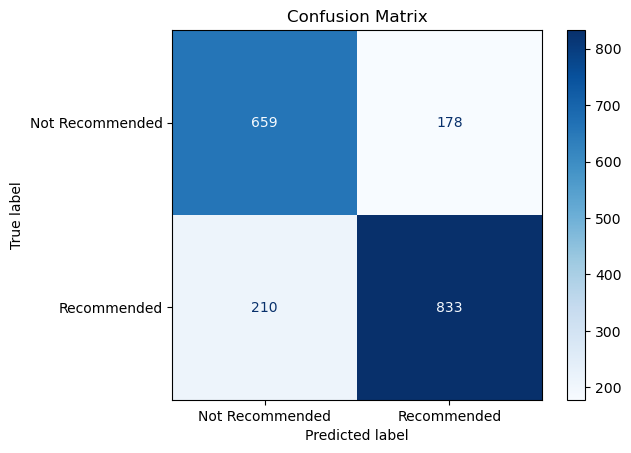

In [104]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_final)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rating_encoder_text.classes_)

disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

In [102]:
import joblib
joblib.dump(final_model, "svc_tfidf_model.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")
joblib.dump(rating_encoder_text, "rating_encoder.pkl")

['rating_encoder.pkl']

In [103]:
joblib.dump(rec_df, "rec_df.pkl")
joblib.dump(indices, "indices.pkl")
joblib.dump(cosine_sim, "cosine_sim.pkl")

['cosine_sim.pkl']